# Paged Attention & KV Cache Experiments
**Builds on `01_transformer_from_scratch.ipynb` (LLaMA architecture)**

---

### The Problem with Naive KV Cache
```
Naive cache (notebook 01):          Paged Attention (this notebook):

seq_A: [k0,k1,k2,...,k511]          Physical KV pool: 512 blocks × 16 slots
seq_B: [k0,k1,k2,...,k511]          ┌──────┬──────┬──────┬──────┐
                                     │blk 0 │blk 1 │blk 3 │blk 7 │  ← seq_A
Pre-allocate max_seq_len for each    ├──────┼──────┼──────┼──────┤
sequence regardless of actual use    │blk 2 │blk 5 │      │      │  ← seq_B
→ massive fragmentation waste        └──────┴──────┴──────┴──────┘
```

| Component | What it does |
|---|---|
| `BlockAllocator` | Free-list manager — allocates / frees physical blocks |
| `BlockTable` | Per-sequence logical→physical block mapping |
| `PagedKVCache` | Physical KV storage pool; read/write via block table |
| `PagedAttention` | Attention kernel that gathers K/V from paged memory |
| `PagedLLaMAAttention` | Drop-in replacement for `LLaMAAttention` |
| `PagedLLaMA` | Full LLaMA model with paged KV |
| `PagedInferenceEngine` | Batched generation with block table management |

### Memory Layout
```
Physical KV pool  shape: (n_blocks, BLOCK_SIZE, n_kv_heads, head_dim)
                                                                        
block_table[seq_id] = [3, 7, 1, ...]   ← list of physical block ids
                                                                        
  Let's say you have a sequence of 35 tokens and BLOCK_SIZE = 16.
  Logical positions:   0  1  2 ... 15 | 16 17 18 ... 31 | 32 33 34
                     └── block 0 ──┘  └──── block 1 ──┘  └─ block 2 ┘
  These are logical blocks — just 0, 1, 2 in order.
  Each logical block maps to a physical block
  The physical blocks are wherever the allocator found free space in the pool. They don't have to be in order:
  block_table = [3, 7, 11]
                 ↑  ↑   ↑
             blk0=3 blk1=7 blk2=11   (physical block ids)     
 Looking up token at logical position 20
 block_idx   = 20 // 16 = 1        → "it's in logical block 1"
slot_offset = 20 %  16 = 4        → "it's the 4th slot inside that block"

physical block = block_table[1] = 7   → "logical block 1 lives at physical block 7"

final address = pool[7, 4, :, :]      → block 7, slot 4
```

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 1. Setup — Paste LLaMA Backbone from Notebook 01

All the LLaMA building blocks from notebook 01 are pasted here so this notebook is self-contained.
Only `LLaMAAttention` will be replaced by `PagedLLaMAAttention`.

In [2]:
!pip install -q sentencepiece transformers
import torch, math, time, os
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from dataclasses import dataclass, field
from typing import Optional, Tuple, List, Dict

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype  = torch.float16
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
torch.manual_seed(42)

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# LLaMA backbone — copied verbatim from 01_transformer_from_scratch.ipynb
# (RMSNorm, RoPE, SwiGLU, repeat_kv, LLaMAConfig)
# LLaMAAttention is NOT included here — replaced by PagedLLaMAAttention
# ═══════════════════════════════════════════════════════════════════════════

@dataclass
class LLaMAConfig:
    vocab_size   : int   = 32000
    dim          : int   = 768
    n_layers     : int   = 12
    n_heads      : int   = 12
    n_kv_heads   : int   = 6
    max_seq_len  : int   = 512
    ffn_dim_mult : float = 2.6875
    norm_eps     : float = 1e-5
    rope_theta   : float = 10000.0
    dropout      : float = 0.0
    grad_checkpoint: bool = False

    @property
    def head_dim(self):
        return self.dim // self.n_heads

    @property
    def ffn_hidden_dim(self):
        raw = int(self.ffn_dim_mult * self.dim)
        return (raw + 255) // 256 * 256


# ── RMSNorm ─────────────────────────────────────────────────────────────────
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-5):
        super().__init__()
        self.eps   = eps
        self.gamma = nn.Parameter(torch.ones(dim))

    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        return self.gamma * self._norm(x.float()).type_as(x)


# ── RoPE ────────────────────────────────────────────────────────────────────
def precompute_rope_freqs(head_dim, max_seq_len, theta=10000.0, device='cpu'):
    freqs = 1.0 / (theta ** (
        torch.arange(0, head_dim, 2, dtype=torch.float32, device=device) / head_dim
    ))
    t     = torch.arange(max_seq_len, dtype=torch.float32, device=device)
    freqs = torch.outer(t, freqs)
    cos_t = torch.cos(freqs).repeat_interleave(2, dim=-1)
    sin_t = torch.sin(freqs).repeat_interleave(2, dim=-1)
    return cos_t, sin_t

def rotate_half(x):
    x1, x2 = x[..., 0::2], x[..., 1::2]
    return torch.stack([-x2, x1], dim=-1).flatten(-2)

def apply_rope(q, k, cos, sin):
    cos = cos.unsqueeze(0).unsqueeze(0)
    sin = sin.unsqueeze(0).unsqueeze(0)
    return (q * cos + rotate_half(q) * sin).type_as(q), \
           (k * cos + rotate_half(k) * sin).type_as(k)


# ── GQA helper ──────────────────────────────────────────────────────────────
def repeat_kv(x, n_rep):
    if n_rep == 1:
        return x
    B, n_kv, T, hd = x.shape
    return (x[:, :, None, :, :]
            .expand(B, n_kv, n_rep, T, hd)
            .reshape(B, n_kv * n_rep, T, hd))


# ── SwiGLU FFN ──────────────────────────────────────────────────────────────
class SwiGLUFFN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        h = cfg.ffn_hidden_dim
        self.w1   = nn.Linear(cfg.dim, h, bias=False)
        self.w2   = nn.Linear(h, cfg.dim, bias=False)
        self.w3   = nn.Linear(cfg.dim, h, bias=False)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.drop(self.w2(F.silu(self.w3(x)) * self.w1(x)))


# ── Precompute RoPE tables ───────────────────────────────────────────────────
cfg = LLaMAConfig()
cos_table, sin_table = precompute_rope_freqs(
    cfg.head_dim, cfg.max_seq_len, cfg.rope_theta, device
)
print(' Backbone loaded')
print(f'   dim={cfg.dim}  n_layers={cfg.n_layers}  n_heads={cfg.n_heads}  head_dim={cfg.head_dim}')

 Backbone loaded
   dim=768  n_layers=12  n_heads=12  head_dim=64


---
## 2. Paged Attention Constants

```
BLOCK_SIZE = 16   ← tokens per block

Physical memory pool layout:

pool_K shape: (n_layers, n_total_blocks, BLOCK_SIZE, n_kv_heads, head_dim)
pool_V shape: (n_layers, n_total_blocks, BLOCK_SIZE, n_kv_heads, head_dim)

n_total_blocks = total_kv_memory_tokens // BLOCK_SIZE
              = (max_seqs × max_seq_len) // BLOCK_SIZE
```

In [22]:
BLOCK_SIZE    = 16
MAX_SEQS      = 8
MAX_SEQ_LEN   = 512

# Logical blocks needed to serve all sequences
N_LOGICAL_BLOCKS = math.ceil((MAX_SEQS * MAX_SEQ_LEN) / BLOCK_SIZE)   # = 256

# Total allocator slots = logical blocks × n_layers
# because each logical block consumes one slot PER LAYER
N_TOTAL_BLOCKS = N_LOGICAL_BLOCKS * cfg.n_layers   # = 256 × 12 = 3072

MAX_BLOCKS_PER_SEQ = math.ceil(MAX_SEQ_LEN / BLOCK_SIZE)   # = 32 logical blocks
                                                             # = 32 × 12 = 384 slots

print('Paged Attention Memory Layout')
print(f'  BLOCK_SIZE            = {BLOCK_SIZE} tokens')
print(f'  N_LOGICAL_BLOCKS      = {N_LOGICAL_BLOCKS}  (logical, shared concept)')
print(f'  N_TOTAL_BLOCKS        = {N_TOTAL_BLOCKS}  (allocator slots = logical × {cfg.n_layers} layers)')
print(f'  MAX_BLOCKS_PER_SEQ    = {MAX_BLOCKS_PER_SEQ} logical blocks per seq')
print(f'  MAX_SEQS              = {MAX_SEQS}')

# Memory at max capacity
kv_pool_bytes = (
    2                    # K and V
    * N_LOGICAL_BLOCKS   # logical blocks
    * BLOCK_SIZE
    * cfg.n_kv_heads
    * cfg.head_dim
    * cfg.n_layers       # one tensor per layer per logical block
    * 2                  # fp16
)
print(f'  KV pool at max capacity = {kv_pool_bytes/1e6:.1f} MB  (fp16)')
print(f'  vs naive cache          = {2 * cfg.n_layers * MAX_SEQS * MAX_SEQ_LEN * cfg.n_kv_heads * cfg.head_dim * 2 / 1e6:.1f} MB')

Paged Attention Memory Layout
  BLOCK_SIZE            = 16 tokens
  N_LOGICAL_BLOCKS      = 256  (logical, shared concept)
  N_TOTAL_BLOCKS        = 3072  (allocator slots = logical × 12 layers)
  MAX_BLOCKS_PER_SEQ    = 32 logical blocks per seq
  MAX_SEQS              = 8
  KV pool at max capacity = 75.5 MB  (fp16)
  vs naive cache          = 75.5 MB


---
## 3. BlockAllocator — Free-List Manager

```
free_blocks = deque([0, 1, 2, 3, ..., 255])   ← all blocks start free

allocate(n=3)  → pops  [0, 1, 2]     free_blocks = [3, 4, ..., 255]
free([1])      → appends 1 back      free_blocks = [3, 4, ..., 255, 1]
```

This mirrors how vLLM's block manager works — a simple free-list over physical block ids.

In [23]:
from collections import deque

class BlockAllocator:
    """
    Manages a pool of physical KV blocks via a free-list.

    Physical block id = integer in [0, n_total_blocks)
    Sequences request blocks as they grow and return them when done.
    """

    def __init__(self, n_total_blocks: int):
        self.n_total      = n_total_blocks
        self._free        = deque(range(n_total_blocks))  # all blocks start free
        self._ref_count   = [0] * n_total_blocks          # for future copy-on-write

    # ── Allocation ──────────────────────────────────────────────────────────
    def allocate(self, n: int = 1) -> List[int]:
        """
        Pop `n` free blocks from the free-list.
        Raises RuntimeError if not enough blocks available.
        """
        if len(self._free) < n:
            raise RuntimeError(
                f'Out of KV blocks! Requested {n}, only {len(self._free)} free '
                f'out of {self.n_total} total. Consider freeing sequences.'
            )
        blocks = [self._free.popleft() for _ in range(n)]
        for b in blocks:
            self._ref_count[b] = 1
        return blocks

    def free(self, block_ids: List[int]):
        """Return blocks to the free-list."""
        for b in block_ids:
            self._ref_count[b] -= 1
            if self._ref_count[b] == 0:
                self._free.append(b)

    # ── Stats ────────────────────────────────────────────────────────────────
    @property
    def n_free(self):
        return len(self._free)

    @property
    def n_used(self):
        return self.n_total - self.n_free

    def utilization(self) -> float:
        return self.n_used / self.n_total

    def __repr__(self):
        return (f'BlockAllocator(total={self.n_total}, '
                f'free={self.n_free}, used={self.n_used}, '
                f'util={self.utilization():.1%})')


# ── Unit test ────────────────────────────────────────────────────────────────
alloc = BlockAllocator(N_TOTAL_BLOCKS)
print(f'Initial state : {alloc}')

b1 = alloc.allocate(3)
print(f'After alloc(3): {alloc}  blocks={b1}')

b2 = alloc.allocate(5)
print(f'After alloc(5): {alloc}  blocks={b2}')

alloc.free(b1)
print(f'After free(b1): {alloc}')

# Verify freed blocks come back
b3 = alloc.allocate(2)
print(f'After alloc(2): {alloc}  blocks={b3}  (reused freed blocks)')

# Reset for actual use
alloc = BlockAllocator(N_TOTAL_BLOCKS)

Initial state : BlockAllocator(total=3072, free=3072, used=0, util=0.0%)
After alloc(3): BlockAllocator(total=3072, free=3069, used=3, util=0.1%)  blocks=[0, 1, 2]
After alloc(5): BlockAllocator(total=3072, free=3064, used=8, util=0.3%)  blocks=[3, 4, 5, 6, 7]
After free(b1): BlockAllocator(total=3072, free=3067, used=5, util=0.2%)
After alloc(2): BlockAllocator(total=3072, free=3065, used=7, util=0.2%)  blocks=[8, 9]  (reused freed blocks)


---
## 4. BlockTable — Logical → Physical Mapping

Each active sequence has its own `BlockTable`:

```
Sequence A, 35 tokens written so far (BLOCK_SIZE=16):

logical block 0 → physical block 7   (tokens  0-15)
logical block 1 → physical block 3   (tokens 16-31)
logical block 2 → physical block 11  (tokens 32-34)  ← partially filled

block_table = [7, 3, 11]
num_tokens  = 35
          
```

In [24]:
class LayeredBlockTable:
    """
    Per-sequence logical-to-physical block mapping — LAYER-AWARE.

    Each logical block gets n_layers SEPARATE physical block ids,
    one per layer. This means the BlockAllocator tracks real 1:1
    physical units — one block_id = one tensor in exactly one layer.

    block_ids[layer_idx][logical_block_idx] = physical_block_id

    Example (n_layers=12, BLOCK_SIZE=16, 17 tokens):
      logical block 0 allocated → allocate(12) → ids [0..11]
        layer 0  → physical block 0   pool_k[0][0]  = tensor(16,6,64)
        layer 1  → physical block 1   pool_k[1][1]  = tensor(16,6,64)
        ...
        layer 11 → physical block 11  pool_k[11][11] = tensor(16,6,64)
      logical block 1 allocated → allocate(12) → ids [12..23]
        layer 0  → physical block 12
        ...
    """

    def __init__(self, seq_id: int, n_layers: int, block_size: int = BLOCK_SIZE):
        self.seq_id     = seq_id
        self.n_layers   = n_layers
        self.block_size = block_size
        self.num_tokens = 0
        # block_ids[layer_idx][logical_block_idx] = physical_block_id
        self.block_ids: List[List[int]] = [[] for _ in range(n_layers)]

    # ── Properties ──────────────────────────────────────────────────────────
    @property
    def num_blocks(self) -> int:
        """Number of logical blocks (same count in every layer)."""
        return len(self.block_ids[0])

    @property
    def last_block_is_full(self) -> bool:
        return self.num_tokens > 0 and (self.num_tokens % self.block_size) == 0

    @property
    def last_block_offset(self) -> int:
        return self.num_tokens % self.block_size

    # ── Token append ────────────────────────────────────────────────────────
    def append_token(self, allocator: 'BlockAllocator', kv_cache=None):
        """
        When a new logical block is needed:
          - Allocate n_layers SEPARATE physical block ids (one per layer)
          - Provision the GPU tensor for each (layer, block_id) pair
        Each block_id is truly unique and belongs to exactly one layer.
        """
        if self.num_blocks == 0 or self.last_block_is_full:
            # Allocate n_layers block ids at once — one per layer
            new_ids = allocator.allocate(self.n_layers)
            for layer_idx in range(self.n_layers):
                phys_id = new_ids[layer_idx]
                self.block_ids[layer_idx].append(phys_id)
                if kv_cache is not None:
                    kv_cache.allocate_block_for_layer(layer_idx, phys_id)
        self.num_tokens += 1

    def append_tokens(self, n: int, allocator: 'BlockAllocator', kv_cache=None):
        for _ in range(n):
            self.append_token(allocator, kv_cache)

    # ── Address translation ──────────────────────────────────────────────────
    def translate(self, layer: int, logical_pos: int) -> Tuple[int, int]:
        """
        Convert logical token position → (physical_block_id, slot_offset)
        FOR A SPECIFIC LAYER.

        Each layer has its own physical block id for the same logical position.

        Example (BLOCK_SIZE=16, layer=3):
          logical_pos=20 → logical_block=1, slot=4
                         → phys_block = block_ids[3][1]  ← layer 3's own block
                         → pool_k[3][phys_block][4]
        """
        logical_block  = logical_pos // self.block_size
        slot_offset    = logical_pos %  self.block_size
        physical_block = self.block_ids[layer][logical_block]
        return physical_block, slot_offset

    def get_all_physical_slots(self, layer: int) -> Tuple[List[int], List[int]]:
        """Returns (physical_block_ids, slots) for all tokens for a specific layer."""
        phys_blocks, slots = [], []
        for pos in range(self.num_tokens):
            pb, so = self.translate(layer, pos)
            phys_blocks.append(pb)
            slots.append(so)
        return phys_blocks, slots

    # ── Free ────────────────────────────────────────────────────────────────
    def free(self, allocator: 'BlockAllocator', kv_cache=None):
        """Return all physical block ids (across all layers) to the allocator."""
        # Flatten all per-layer block ids into one list
        all_ids = [bid for layer_ids in self.block_ids for bid in layer_ids]
        if kv_cache is not None:
            kv_cache.free_blocks(all_ids)
        allocator.free(all_ids)
        self.block_ids  = [[] for _ in range(self.n_layers)]
        self.num_tokens = 0

    def __repr__(self):
        return (f'LayeredBlockTable(seq={self.seq_id}, tokens={self.num_tokens}, '
                f'blocks_per_layer={self.num_blocks}, '
                f'layer0_ids={self.block_ids[0]})')


# ── Unit test ────────────────────────────────────────────────────────────────
# Use a small n_layers=3 so output is readable
_test_layers = 3
alloc  = BlockAllocator(N_TOTAL_BLOCKS)
bt     = LayeredBlockTable(seq_id=0, n_layers=_test_layers)

print('=== LayeredBlockTable walkthrough (BLOCK_SIZE=16, n_layers=3) ===')
print(f'Initial: {bt}')

# Simulate prefill of 35 tokens
bt.append_tokens(35, alloc)
print(f'After 35 tokens: {bt}')
print(f'  Allocator used: {alloc.n_used} blocks  '
      f'(= {bt.num_blocks} logical blocks × {_test_layers} layers)')
for li in range(_test_layers):
    print(f'  layer {li} physical ids: {bt.block_ids[li]}')

# Decode step
bt.append_token(alloc)
print(f'After 36 tokens: {bt}')

# Address translation — each layer has its own physical block
print('\nAddress translation for logical_pos=20:')
for li in range(_test_layers):
    pb, so = bt.translate(li, 20)
    print(f'  layer {li}: phys_block={pb}  slot={so}  → pool_k[{li}][{pb}][{so}]')

bt.free(alloc)
print(f'After free: {bt}')
print(f'Allocator : {alloc}')

# Reset allocator for subsequent cells
alloc = BlockAllocator(N_TOTAL_BLOCKS)


=== LayeredBlockTable walkthrough (BLOCK_SIZE=16, n_layers=3) ===
Initial: LayeredBlockTable(seq=0, tokens=0, blocks_per_layer=0, layer0_ids=[])
After 35 tokens: LayeredBlockTable(seq=0, tokens=35, blocks_per_layer=3, layer0_ids=[0, 3, 6])
  Allocator used: 9 blocks  (= 3 logical blocks × 3 layers)
  layer 0 physical ids: [0, 3, 6]
  layer 1 physical ids: [1, 4, 7]
  layer 2 physical ids: [2, 5, 8]
After 36 tokens: LayeredBlockTable(seq=0, tokens=36, blocks_per_layer=3, layer0_ids=[0, 3, 6])

Address translation for logical_pos=20:
  layer 0: phys_block=3  slot=4  → pool_k[0][3][4]
  layer 1: phys_block=4  slot=4  → pool_k[1][4][4]
  layer 2: phys_block=5  slot=4  → pool_k[2][5][4]
After free: LayeredBlockTable(seq=0, tokens=0, blocks_per_layer=0, layer0_ids=[])
Allocator : BlockAllocator(total=3072, free=3072, used=0, util=0.0%)


---
## 5. PagedKVCache — Physical Storage Pool

```
Physical pool (per layer):

  pool_k : (N_TOTAL_BLOCKS, BLOCK_SIZE, n_kv_heads, head_dim)  fp16
  pool_v : (N_TOTAL_BLOCKS, BLOCK_SIZE, n_kv_heads, head_dim)  fp16

Write (called during prefill/decode):
  pool_k[physical_block, slot_offset, :, :] = k_vector

Read (called during attention):
  gather all (physical_block, slot) pairs for a sequence
  → returns (seq_len, n_kv_heads, head_dim) tensor
```

In [25]:
class PagedKVCache:
    """
    Physical KV storage — each block_id maps to exactly ONE layer.

    pool_k[layer][block_id] → tensor(BLOCK_SIZE, n_kv_heads, head_dim)

    LayeredBlockTable ensures each layer gets its own block_id, so
    the allocator tracks real 1:1 physical units.

    Memory is allocated on demand via allocate_block_for_layer(),
    called from LayeredBlockTable.append_token().
    """

    def __init__(
        self,
        n_layers      : int,
        n_total_blocks: int,
        block_size    : int,
        n_kv_heads    : int,
        head_dim      : int,
        dtype         : torch.dtype = torch.float16,
        device        : str = 'cuda',
    ):
        self.n_layers       = n_layers
        self.n_total_blocks = n_total_blocks
        self.block_size     = block_size
        self.n_kv_heads     = n_kv_heads
        self.head_dim       = head_dim
        self.dtype          = dtype
        self.device         = device

        # pool_k[layer][block_id] = tensor(BLOCK_SIZE, n_kv_heads, head_dim)
        # Nothing allocated at init — grows as tokens arrive
        self.pool_k: List[Dict[int, torch.Tensor]] = [{} for _ in range(n_layers)]
        self.pool_v: List[Dict[int, torch.Tensor]] = [{} for _ in range(n_layers)]

        block_mb = block_size * n_kv_heads * head_dim * 2 / 1e6   # one block, one layer, fp16
        print(f'PagedKVCache ready (dynamic, layer-aware) — 0 MB used at start')
        print(f'  block shape per layer: ({block_size}, {n_kv_heads}, {head_dim})  = {block_mb:.4f} MB each')
        print(f'  one logical block costs: {block_mb * n_layers * 2:.3f} MB  '
              f'({n_layers} layers × K+V)')
        print(f'  max capacity: {n_total_blocks} total block slots = '
              f'{n_total_blocks // n_layers} logical blocks max')

    # ── Allocate: one tensor for ONE layer at ONE block_id ───────────────────
    def allocate_block_for_layer(self, layer: int, block_id: int):
        """
        Allocate GPU memory for a single (layer, block_id) pair.
        Called n_layers times per logical block (once per layer).
        This is the ONLY place GPU memory for KV is touched.
        """
        shape = (self.block_size, self.n_kv_heads, self.head_dim)
        if block_id not in self.pool_k[layer]:
            self.pool_k[layer][block_id] = torch.zeros(shape, dtype=self.dtype, device=self.device)
            self.pool_v[layer][block_id] = torch.zeros(shape, dtype=self.dtype, device=self.device)

    def free_blocks(self, block_ids: List[int]):
        """
        Release GPU tensors for a list of block_ids.
        Each block_id belongs to exactly one layer — we search all layers
        but only the owning layer will have it in its dict.
        """
        for bid in block_ids:
            for layer in range(self.n_layers):
                self.pool_k[layer].pop(bid, None)
                self.pool_v[layer].pop(bid, None)

    # ── Write ────────────────────────────────────────────────────────────────
    def write_slot(self, layer: int, block_id: int, slot: int,
                   k: torch.Tensor, v: torch.Tensor):
        self.pool_k[layer][block_id][slot] = k.to(self.dtype)
        self.pool_v[layer][block_id][slot] = v.to(self.dtype)

    def write_tokens(
        self,
        layer: int,
        block_table: 'LayeredBlockTable',
        k_seq      : torch.Tensor,   # (T, n_kv_heads, head_dim)
        v_seq      : torch.Tensor,   # (T, n_kv_heads, head_dim)
        start_pos  : int = 0,
    ):
        T = k_seq.shape[0]
        for i in range(T):
            # translate now takes layer as first arg — gets layer-specific block_id
            phys_block, slot = block_table.translate(layer, start_pos + i)
            self.write_slot(layer, phys_block, slot, k_seq[i], v_seq[i])

    # ── Read ─────────────────────────────────────────────────────────────────
    def read_sequence(
        self,
        layer      : int,
        block_table: 'LayeredBlockTable',
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Gather K, V for all tokens using layer-specific physical block ids.
        Each layer reads from its own block ids — fully independent.
        """
        phys_blocks, slots = block_table.get_all_physical_slots(layer)
        k_list = [self.pool_k[layer][pb][s] for pb, s in zip(phys_blocks, slots)]
        v_list = [self.pool_v[layer][pb][s] for pb, s in zip(phys_blocks, slots)]
        return torch.stack(k_list), torch.stack(v_list)

    # ── Stats ─────────────────────────────────────────────────────────────────
    def allocated_blocks(self) -> int:
        """Total allocated (layer, block_id) pairs across all layers."""
        return sum(len(d) for d in self.pool_k)

    def allocated_logical_blocks(self) -> int:
        """Logical blocks = physical blocks / n_layers."""
        return self.allocated_blocks() // max(self.n_layers, 1)

    def memory_used_mb(self) -> float:
        """Actual GPU memory consumed by all allocated tensors."""
        n = self.allocated_blocks()   # total (layer, block) pairs
        return n * self.block_size * self.n_kv_heads * self.head_dim * 2 / 1e6

    def __repr__(self):
        return (f'PagedKVCache(logical_blocks={self.allocated_logical_blocks()}, '
                f'total_tensors={self.allocated_blocks()}, '
                f'memory={self.memory_used_mb():.2f} MB)')


# ── Instantiate KV pool ──────────────────────────────────────────────────────
kv_cache = PagedKVCache(
    n_layers       = cfg.n_layers,
    n_total_blocks = N_TOTAL_BLOCKS,
    block_size     = BLOCK_SIZE,
    n_kv_heads     = cfg.n_kv_heads,
    head_dim       = cfg.head_dim,
    dtype          = torch.float16,
    device         = device,
)

# ── Smoke test ───────────────────────────────────────────────────────────────
alloc = BlockAllocator(N_TOTAL_BLOCKS)
bt    = LayeredBlockTable(seq_id=99, n_layers=cfg.n_layers)
bt.append_tokens(35, alloc, kv_cache)

print(f'After 35 tokens: {bt}')
print(f'KV cache: {kv_cache}')
print(f'Allocator used: {alloc.n_used} physical block slots '
      f'({bt.num_blocks} logical blocks × {cfg.n_layers} layers)')

# Write fake K/V into layer 0
fake_k = torch.randn(35, cfg.n_kv_heads, cfg.head_dim, device=device)
fake_v = torch.randn(35, cfg.n_kv_heads, cfg.head_dim, device=device)
kv_cache.write_tokens(layer=0, block_table=bt, k_seq=fake_k, v_seq=fake_v, start_pos=0)

# Read back from layer 0
k_r, v_r = kv_cache.read_sequence(layer=0, block_table=bt)
print(f'Write 35 tokens → Read back: k={k_r.shape}  v={v_r.shape}')

assert torch.allclose(fake_k.half(), k_r, atol=1e-3), 'K mismatch!'
assert torch.allclose(fake_v.half(), v_r, atol=1e-3), 'V mismatch!'
print('PagedKVCache read/write round-trip verified')

# Verify layer isolation — layer 1 should have zeros (not written yet)
k_l1, _ = kv_cache.read_sequence(layer=1, block_table=bt)
assert k_l1.abs().max().item() == 0.0, 'Layer isolation broken!'
print('Layer isolation verified (layer 1 untouched by layer 0 writes)')

bt.free(alloc, kv_cache)
print(f'After free: {kv_cache}')   # should show 0 MB
assert kv_cache.memory_used_mb() == 0.0, 'Memory leak!'
print('No memory leak after free')

alloc = BlockAllocator(N_TOTAL_BLOCKS)  # reset


PagedKVCache ready (dynamic, layer-aware) — 0 MB used at start
  block shape per layer: (16, 6, 64)  = 0.0123 MB each
  one logical block costs: 0.295 MB  (12 layers × K+V)
  max capacity: 3072 total block slots = 256 logical blocks max
After 35 tokens: LayeredBlockTable(seq=99, tokens=35, blocks_per_layer=3, layer0_ids=[0, 12, 24])
KV cache: PagedKVCache(logical_blocks=3, total_tensors=36, memory=0.44 MB)
Allocator used: 36 physical block slots (3 logical blocks × 12 layers)
Write 35 tokens → Read back: k=torch.Size([35, 6, 64])  v=torch.Size([35, 6, 64])
PagedKVCache read/write round-trip verified
Layer isolation verified (layer 1 untouched by layer 0 writes)
After free: PagedKVCache(logical_blocks=0, total_tensors=0, memory=0.00 MB)
No memory leak after free


---
## 6. PagedAttention — Gather-Based Attention Kernel

```
Standard attention (contiguous K/V):
  scores = Q @ K^T          K shape: (B, n_heads, T, head_dim)

Paged attention:
  Step 1: GATHER  K, V from scattered physical blocks → (T, n_kv_heads, head_dim)
  Step 2: Reshape gathered K/V to (1, n_heads, T, head_dim)
  Step 3: Standard attention with gathered K/V

The gather replaces contiguous cache lookup.
```

In [26]:
def paged_attention(
    q           : torch.Tensor,       # (1, n_heads, T_q, head_dim)  — query tokens
    layer_idx   : int,
    block_table : LayeredBlockTable,
    kv_cache    : PagedKVCache,
    n_heads     : int,
    n_kv_heads  : int,
    head_dim    : int,
    start_pos   : int,
    causal_mask : Optional[torch.Tensor] = None,
    dropout_p   : float = 0.0,
) -> torch.Tensor:
    """
    Paged attention for a SINGLE sequence.

    Unlike standard attention that reads from contiguous K/V tensors,
    this function:
      1. Gathers K/V from the physical block pool using the block table
      2. Runs standard scaled dot-product attention

    This is the functional core of vLLM's paged attention.
    """
    T_q = q.shape[2]   # number of query tokens (full seq during prefill, 1 during decode)
    n_rep = n_heads // n_kv_heads

    # ── 1. Gather K, V from paged pool ───────────────────────────────────
    # k_gathered : (T_kv, n_kv_heads, head_dim)  — ALL past + current tokens
    k_gathered, v_gathered = kv_cache.read_sequence(layer_idx, block_table)
    T_kv = k_gathered.shape[0]

    # ── 2. Reshape to attention-compatible layout ─────────────────────────
    # (T_kv, n_kv_heads, head_dim) → (1, n_kv_heads, T_kv, head_dim)
    k = k_gathered.permute(1, 0, 2).unsqueeze(0).to(q.dtype)  # (1, nkv, T_kv, hd)
    v = v_gathered.permute(1, 0, 2).unsqueeze(0).to(q.dtype)  # (1, nkv, T_kv, hd)

    # ── 3. GQA: expand K/V heads to match Q heads ─────────────────────────
    k = repeat_kv(k, n_rep)   # (1, n_heads, T_kv, head_dim)
    v = repeat_kv(v, n_rep)   # (1, n_heads, T_kv, head_dim)

    # ── 4. Scaled dot-product attention ──────────────────────────────────
    scale  = 1.0 / math.sqrt(head_dim)
    scores = torch.matmul(q, k.transpose(-2, -1)) * scale   # (1, n_heads, T_q, T_kv)

    # ── 5. Causal mask ────────────────────────────────────────────────────
    # During decode T_q=1: query can attend to all past tokens → no masking needed
    # During prefill T_q>1: apply standard causal mask
    if causal_mask is not None and T_q > 1:
        scores = scores + causal_mask[:, :, start_pos:start_pos+T_q, :T_kv]

    # ── 6. Softmax ────────────────────────────────────────────────────────
    weights = F.softmax(scores.float(), dim=-1).to(q.dtype)
    if dropout_p > 0.0:
        weights = F.dropout(weights, p=dropout_p)

    # ── 7. Weighted sum ───────────────────────────────────────────────────
    out = torch.matmul(weights, v)                           # (1, n_heads, T_q, head_dim)
    out = out.transpose(1, 2).contiguous()                   # (1, T_q, n_heads, head_dim)
    out = out.view(1, T_q, n_heads * head_dim)               # (1, T_q, dim)
    return out


print('paged_attention function defined')

paged_attention function defined


---
## 7. PagedLLaMAAttention — Drop-in Replacement Layer

In [27]:
class PagedLLaMAAttention(nn.Module):
    """
    LLaMA attention layer with paged KV cache.

    Differences from LLaMAAttention (notebook 01):
      • No self.cache_k / self.cache_v tensors on the module
      • K/V are written to the external PagedKVCache during forward
      • Attention is computed by gathering from PagedKVCache via block table
      • Each call receives a block_table for the active sequence
    """

    def __init__(self, cfg: LLaMAConfig, layer_idx: int):
        super().__init__()
        self.n_heads    = cfg.n_heads
        self.n_kv_heads = cfg.n_kv_heads
        self.n_rep      = cfg.n_heads // cfg.n_kv_heads
        self.head_dim   = cfg.head_dim
        self.dim        = cfg.dim
        self.layer_idx  = layer_idx
        self.dropout_p  = cfg.dropout

        # Projections (no bias — LLaMA)
        self.wq = nn.Linear(cfg.dim, cfg.n_heads    * cfg.head_dim, bias=False)
        self.wk = nn.Linear(cfg.dim, cfg.n_kv_heads * cfg.head_dim, bias=False)
        self.wv = nn.Linear(cfg.dim, cfg.n_kv_heads * cfg.head_dim, bias=False)
        self.wo = nn.Linear(cfg.n_heads * cfg.head_dim, cfg.dim,    bias=False)

    def forward(
        self,
        x           : torch.Tensor,       # (1, T, dim)   single sequence
        cos         : torch.Tensor,       # (max_seq_len, head_dim)
        sin         : torch.Tensor,       # (max_seq_len, head_dim)
        block_table : LayeredBlockTable,
        kv_cache    : PagedKVCache,
        causal_mask : Optional[torch.Tensor],
        start_pos   : int,
    ) -> torch.Tensor:
        B, T, _ = x.shape
        assert B == 1, 'PagedLLaMAAttention processes one sequence at a time'

        # ── 1. Project Q, K, V ───────────────────────────────────────────
        q = self.wq(x).view(B, T, self.n_heads,    self.head_dim).transpose(1, 2)
        k = self.wk(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = self.wv(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)

        # ── 2. Apply RoPE ────────────────────────────────────────────────
        c = cos[start_pos : start_pos + T]
        s = sin[start_pos : start_pos + T]
        q, k = apply_rope(q, k, c, s)

        # ── 3. Write K, V into paged pool ────────────────────────────────
        # k shape: (1, n_kv_heads, T, head_dim) → (T, n_kv_heads, head_dim)
        k_write = k.squeeze(0).permute(1, 0, 2)   # (T, n_kv_heads, head_dim)
        v_write = v.squeeze(0).permute(1, 0, 2)
        kv_cache.write_tokens(
            layer       = self.layer_idx,
            block_table = block_table,
            k_seq       = k_write,
            v_seq       = v_write,
            start_pos   = start_pos,
        )

        # ── 4. Paged attention — gathers K/V from physical pool ──────────
        out = paged_attention(
            q           = q,
            layer_idx   = self.layer_idx,
            block_table = block_table,
            kv_cache    = kv_cache,
            n_heads     = self.n_heads,
            n_kv_heads  = self.n_kv_heads,
            head_dim    = self.head_dim,
            start_pos   = start_pos,
            causal_mask = causal_mask,
            dropout_p   = self.dropout_p if self.training else 0.0,
        )   # (1, T, dim)

        # ── 5. Output projection ─────────────────────────────────────────
        return self.wo(out)   # (1, T, dim)


print(' PagedLLaMAAttention defined')

 PagedLLaMAAttention defined


---
## 8. PagedLLaMA — Full Model

Identical to `LLaMA` from notebook 01 but with:
- `PagedLLaMAAttention` instead of `LLaMAAttention`
- Forward pass receives `block_table` and `kv_cache` arguments

In [28]:
class PagedLLaMABlock(nn.Module):
    def __init__(self, cfg: LLaMAConfig, layer_idx: int):
        super().__init__()
        self.attention_norm = RMSNorm(cfg.dim, eps=cfg.norm_eps)
        self.attention      = PagedLLaMAAttention(cfg, layer_idx)
        self.ffn_norm       = RMSNorm(cfg.dim, eps=cfg.norm_eps)
        self.ffn            = SwiGLUFFN(cfg)

    def forward(
        self,
        x           : torch.Tensor,
        cos         : torch.Tensor,
        sin         : torch.Tensor,
        block_table : LayeredBlockTable,
        kv_cache    : PagedKVCache,
        causal_mask : Optional[torch.Tensor],
        start_pos   : int,
    ) -> torch.Tensor:
        h = x + self.attention(
            self.attention_norm(x),
            cos, sin, block_table, kv_cache, causal_mask, start_pos
        )
        return h + self.ffn(self.ffn_norm(h))


class PagedLLaMA(nn.Module):
    """
    Full LLaMA model with paged KV cache.

    The model itself is stateless w.r.t. KV cache — all state lives in
    the external (PagedKVCache, BlockTable) pair passed in at forward time.
    This makes it easy to serve multiple sequences with independent caches.
    """

    def __init__(self, cfg: LLaMAConfig):
        super().__init__()
        self.cfg = cfg

        self.token_emb = nn.Embedding(cfg.vocab_size, cfg.dim)
        self.layers    = nn.ModuleList([
            PagedLLaMABlock(cfg, i) for i in range(cfg.n_layers)
        ])
        self.norm    = RMSNorm(cfg.dim, eps=cfg.norm_eps)
        self.lm_head = nn.Linear(cfg.dim, cfg.vocab_size, bias=False)
        self.token_emb.weight = self.lm_head.weight

        # Causal mask (additive, -inf for future)
        mask = torch.full((1, 1, cfg.max_seq_len, cfg.max_seq_len), float('-inf'))
        mask = torch.triu(mask, diagonal=1)
        self.register_buffer('causal_mask', mask)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(
        self,
        idx         : torch.Tensor,   # (1, T)
        block_table : LayeredBlockTable,
        kv_cache    : PagedKVCache,
        start_pos   : int = 0,
    ) -> torch.Tensor:
        """
        Forward pass for a single sequence.
        Returns logits: (1, T, vocab_size)
        The model does NOT manage the block_table — caller does.
        """
        B, T = idx.shape
        assert B == 1

        x   = self.token_emb(idx)            # (1, T, dim)
        cos = cos_table.to(x.device)         # full table, layer slices internally
        sin = sin_table.to(x.device)

        for layer in self.layers:
            x = layer(
                x, cos, sin,
                block_table = block_table,
                kv_cache    = kv_cache,
                causal_mask = self.causal_mask,
                start_pos   = start_pos,
            )

        x      = self.norm(x)
        logits = self.lm_head(x)             # (1, T, vocab_size)
        return logits

    def num_parameters(self):
        return sum(p.numel() for p in self.parameters())


# ── Load from checkpoint (notebook 01) ──────────────────────────────────────
CKPT = '/content/drive/MyDrive/PagedInfer/llama_ckpt.pt'

ckpt = torch.load(CKPT, map_location=device, weights_only=True)

# Keep only the fields that LLaMAConfig in this notebook expects
valid_fields = {f.name for f in LLaMAConfig.__dataclass_fields__.values()}
clean_config = {k: v for k, v in ckpt['config'].items() if k in valid_fields}

cfg = LLaMAConfig(**clean_config)

# Rebuild RoPE tables for loaded config
cos_table, sin_table = precompute_rope_freqs(
    cfg.head_dim, cfg.max_seq_len, cfg.rope_theta, device
)

# ── Forward pass smoke test ──────────────────────────────────────────────────
paged_model = PagedLLaMA(cfg).to(device)
paged_model.load_state_dict(ckpt['model_state'])
paged_model.eval()
alloc_test = BlockAllocator(N_TOTAL_BLOCKS)
kv_test    = PagedKVCache(cfg.n_layers, N_TOTAL_BLOCKS, BLOCK_SIZE,
                           cfg.n_kv_heads, cfg.head_dim, device=device)
bt_test    = LayeredBlockTable(seq_id=0, n_layers=cfg.n_layers)
tok_test   = torch.tensor([[1, 2, 3, 4, 5]], device=device)

bt_test.append_tokens(5, alloc_test, kv_test)
print(f'Logical blocks after 5 tokens : {bt_test.num_blocks}')
print(f'All Layer physical ids          : {bt_test.block_ids[:]}')
print(f'Total allocator slots used    : {alloc_test.n_used}  '
      f'(= {bt_test.num_blocks} logical × {cfg.n_layers} layers)')
print(f'KV memory before forward: {kv_test.memory_used_mb():.3f} MB')

with torch.no_grad():
    logits_test = paged_model(tok_test, bt_test, kv_test, start_pos=0)
print(f'Logits shape: {logits_test.shape}')   # (1, 5, 32000)
print(f'KV memory after forward : {kv_test.memory_used_mb():.3f} MB')

bt_test.free(alloc_test, kv_test)
print(f'KV memory after free    : {kv_test.memory_used_mb():.3f} MB')
assert kv_test.memory_used_mb() == 0.0, 'Memory leak!'

PagedKVCache ready (dynamic, layer-aware) — 0 MB used at start
  block shape per layer: (16, 6, 64)  = 0.0123 MB each
  one logical block costs: 0.295 MB  (12 layers × K+V)
  max capacity: 3072 total block slots = 256 logical blocks max
Logical blocks after 5 tokens : 1
All Layer physical ids          : [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11]]
Total allocator slots used    : 12  (= 1 logical × 12 layers)
KV memory before forward: 0.147 MB
Logits shape: torch.Size([1, 5, 32000])
KV memory after forward : 0.147 MB
KV memory after free    : 0.000 MB


---
## 9. PagedInferenceEngine — Batched Generation

```
Engine manages:
  • BlockAllocator  — shared physical block pool
  • PagedKVCache    — physical K/V tensors
  • Per-sequence BlockTables — logical→physical maps
  • Generation state — tokens, status per sequence

Loop:
  for each step:
    1. For each active sequence:
       a. Allocate block if needed
       b. Forward pass (new token only)
       c. Sample next token
       d. Append to sequence; mark done if EOS
    2. Print block table state
    3. Stop when all sequences done
```

In [12]:
from transformers import AutoTokenizer

TOKENIZER_ID = 'huggyllama/llama-7b'
print(f'Loading tokenizer: {TOKENIZER_ID}')
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)
tokenizer.pad_token = tokenizer.eos_token
print(f'Vocab size: {tokenizer.vocab_size}')

Loading tokenizer: huggyllama/llama-7b


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/594 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

Vocab size: 32000


In [29]:
from enum import Enum, auto

class SeqStatus(Enum):
    PREFILL  = auto()   # still processing prompt
    DECODING = auto()   # generating new tokens
    DONE     = auto()   # hit EOS or max_tokens


@dataclass
class SequenceState:
    seq_id      : int
    prompt_str  : str
    token_ids   : List[int]       # all tokens so far (prompt + generated)
    block_table : LayeredBlockTable
    status      : SeqStatus = SeqStatus.PREFILL
    n_generated : int = 0


class PagedInferenceEngine:
    """
    Batched generation engine with paged KV cache.

    Manages:
      - BlockAllocator : shared pool of physical KV blocks
      - PagedKVCache   : physical K/V tensors
      - SequenceState  : per-sequence token list + block table + status

    All sequences share the SAME physical KV pool via their block tables.
    """

    def __init__(
        self,
        model     : PagedLLaMA,
        tokenizer,
        cfg       : LLaMAConfig,
        block_size: int = BLOCK_SIZE,
        n_blocks  : int = N_TOTAL_BLOCKS,
        device    : str = 'cuda',
    ):
        self.model      = model
        self.tokenizer  = tokenizer
        self.cfg        = cfg
        self.block_size = block_size
        self.device     = device

        self.allocator = BlockAllocator(n_blocks)
        self.kv_cache  = PagedKVCache(
            n_layers       = cfg.n_layers,
            n_total_blocks = n_blocks,
            block_size     = block_size,
            n_kv_heads     = cfg.n_kv_heads,
            head_dim       = cfg.head_dim,
            device         = device,
        )
        self.sequences : Dict[int, SequenceState] = {}
        self._next_id  = 0

    # ── Add a prompt ─────────────────────────────────────────────────────────
    def add_request(self, prompt: str) -> int:
        seq_id  = self._next_id
        self._next_id += 1
        tokens  = self.tokenizer.encode(prompt, add_special_tokens=True)
        bt      = LayeredBlockTable(seq_id=seq_id, n_layers=self.cfg.n_layers, block_size=self.block_size)
        self.sequences[seq_id] = SequenceState(
            seq_id      = seq_id,
            prompt_str  = prompt,
            token_ids   = tokens,
            block_table = bt,
        )
        return seq_id

    # ── Prefill one sequence ──────────────────────────────────────────────────
    @torch.no_grad()
    def _prefill(self, seq: SequenceState):
        """Process full prompt, write K/V to paged cache, sample first token."""
        T = len(seq.token_ids)

        # Allocate blocks for all prompt tokens
        seq.block_table.append_tokens(T, self.allocator, self.kv_cache)

        idx = torch.tensor([seq.token_ids], dtype=torch.long, device=self.device)
        with torch.autocast(device_type=self.device, dtype=dtype):
            logits = self.model(idx, seq.block_table, self.kv_cache, start_pos=0)

        # Sample from last position
        next_tok = self._sample(logits[0, -1, :])
        seq.token_ids.append(next_tok)
        seq.n_generated += 1
        seq.status = SeqStatus.DECODING


        if next_tok == self.tokenizer.eos_token_id:
            seq.status = SeqStatus.DONE

    # ── Decode one step for one sequence ─────────────────────────────────────
    @torch.no_grad()
    def _decode_step(self, seq: SequenceState):
        """Forward pass for a single new token, append to block table."""
        seq.block_table.append_token(self.allocator, self.kv_cache)
        start_pos = seq.block_table.num_tokens - 1   # position of new token
        idx       = torch.tensor(
            [[seq.token_ids[-1]]], dtype=torch.long, device=self.device
        )

        with torch.autocast(device_type=self.device, dtype=dtype):
            logits = self.model(idx, seq.block_table, self.kv_cache, start_pos=start_pos)

        next_tok = self._sample(logits[0, -1, :])
        seq.token_ids.append(next_tok)
        seq.n_generated += 1

        if next_tok == self.tokenizer.eos_token_id:
            seq.status = SeqStatus.DONE

    def _sample(
        self,
        logits     : torch.Tensor,
        temperature: float = 0.8,
        top_k      : int   = 50,
    ) -> int:
        logits = logits.float() / temperature
        v, _   = torch.topk(logits, top_k)
        logits[logits < v[-1]] = float('-inf')
        probs  = F.softmax(logits, dim=-1)
        return torch.multinomial(probs, 1).item()

    # ── Free a sequence ───────────────────────────────────────────────────────
    def free_sequence(self, seq_id: int):
        if seq_id in self.sequences:
            self.sequences[seq_id].block_table.free(self.allocator, self.kv_cache)
            del self.sequences[seq_id]

    # ── Main generation loop ──────────────────────────────────────────────────
    def run(
        self,
        max_new_tokens : int = 50,
        verbose        : bool = True,
    ) -> Dict[int, str]:
        """
        Run generation for all pending sequences.
        Returns dict of {seq_id: generated_text}.
        """
        results = {}

        # ── Phase 1: Prefill all sequences ───────────────────────────────
        if verbose:
            print('=== PREFILL ===')
        for seq_id, seq in self.sequences.items():
            if seq.status == SeqStatus.PREFILL:
                self._prefill(seq)
                if verbose:
                    print(f'  seq {seq_id}: prefilled {len(seq.token_ids)-1} prompt tokens  '
                          f'| blocks={seq.block_table.block_ids}')

        if verbose:
            print(f'  Allocator after prefill: {self.allocator}')
            self.print_block_table_state()

        # ── Phase 2: Decode ──────────────────────────────────────────────
        if verbose:
            print('\n=== DECODING ===')

        for step in range(max_new_tokens):
            active = {sid: s for sid, s in self.sequences.items()
                      if s.status == SeqStatus.DECODING}
            if not active:
                break

            for seq_id, seq in active.items():
                if seq.n_generated >= max_new_tokens:
                    seq.status = SeqStatus.DONE
                    continue
                self._decode_step(seq)

            if verbose and step % 10 == 0:
                print(f'  step {step:3d} | active={len(active)} | '
                      f'kv_mem={self.kv_cache.memory_used_mb():.1f} MB | '
                      f'alloc={self.allocator}')
                for sid, seq in active.items():
                    print(f'    seq {sid}: {seq.block_table}  '
                          f'generated={seq.n_generated}')

        # ── Collect results ───────────────────────────────────────────────
        for seq_id, seq in self.sequences.items():
            text = self.tokenizer.decode(seq.token_ids, skip_special_tokens=True)
            results[seq_id] = text

        return results

    # ── Diagnostics ───────────────────────────────────────────────────────────
    def print_block_table_state(self):
        print('\n  Block Table State:')
        print(f'  {"seq_id":<8} {"tokens":<8} {"blocks":<8} {"physical_block_ids"}')
        print(f'  {"-"*60}')
        for seq_id, seq in self.sequences.items():
            bt = seq.block_table
            print(f'  {seq_id:<8} {bt.num_tokens:<8} {bt.num_blocks:<8} {bt.block_ids[0]}')
        print(f'  Allocator: free={self.allocator.n_free}/{self.allocator.n_total}')


print(' PagedInferenceEngine defined')

 PagedInferenceEngine defined


---
## 10. Experiments & Benchmarks

In [30]:
# ── Experiment 1: Single sequence generation with block table trace ──────────
print('='*65)
print('EXPERIMENT 1: Single sequence — block allocation trace')
print('='*65)

engine = PagedInferenceEngine(
    model      = paged_model,
    tokenizer  = tokenizer,
    cfg        = cfg,
    block_size = BLOCK_SIZE,
    n_blocks   = N_TOTAL_BLOCKS,
    device     = device,
)

sid = engine.add_request('Once upon a time there was a little dragon')
print(f'Added seq {sid}')

results = engine.run(max_new_tokens=48, verbose=True)

print('\n=== OUTPUT ===')
print(results[sid])

print(f'\n=== BLOCK TABLE FINAL STATE ===')
bt = engine.sequences[sid].block_table
print(f'Total tokens : {bt.num_tokens}')
print(f'Blocks used  : {bt.num_blocks}')
print(f'Physical ids (layer 0): {bt.block_ids[0]}')
print(f'Slots used in last block: {bt.last_block_offset}/{BLOCK_SIZE}')

# Verify address translations — show layer 0 and layer 1 to prove independence
print(f'\n=== ADDRESS TRANSLATION (BLOCK_SIZE={BLOCK_SIZE}) ===')
print(f'{"pos":>6}  {"layer 0 phys":>14}  {"layer 1 phys":>14}  {"slot":>6}')
print('-' * 50)
for pos in [0, BLOCK_SIZE-1, BLOCK_SIZE, BLOCK_SIZE*2, bt.num_tokens-1]:
    if pos < bt.num_tokens:
        pb0, so = bt.translate(0, pos)   # layer 0
        pb1, _  = bt.translate(1, pos)   # layer 1 — different physical block, same slot
        print(f'{pos:>6}  {pb0:>14}  {pb1:>14}  {so:>6}')

engine.free_sequence(sid)

EXPERIMENT 1: Single sequence — block allocation trace
PagedKVCache ready (dynamic, layer-aware) — 0 MB used at start
  block shape per layer: (16, 6, 64)  = 0.0123 MB each
  one logical block costs: 0.295 MB  (12 layers × K+V)
  max capacity: 3072 total block slots = 256 logical blocks max
Added seq 0
=== PREFILL ===
  seq 0: prefilled 11 prompt tokens  | blocks=[[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11]]
  Allocator after prefill: BlockAllocator(total=3072, free=3060, used=12, util=0.4%)

  Block Table State:
  seq_id   tokens   blocks   physical_block_ids
  ------------------------------------------------------------
  0        11       1        [0]
  Allocator: free=3060/3072

=== DECODING ===
  step   0 | active=1 | kv_mem=0.1 MB | alloc=BlockAllocator(total=3072, free=3060, used=12, util=0.4%)
    seq 0: LayeredBlockTable(seq=0, tokens=12, blocks_per_layer=1, layer0_ids=[0])  generated=2
  step  10 | active=1 | kv_mem=0.3 MB | alloc=BlockAllocator(total=3072, f

In [31]:
# ── Experiment 2: Multi-sequence — see how blocks are shared across seqs ─────
print('='*65)
print('EXPERIMENT 2: Multiple sequences — shared block pool')
print('='*65)

engine2 = PagedInferenceEngine(
    paged_model, tokenizer, cfg,
    block_size=BLOCK_SIZE, n_blocks=N_TOTAL_BLOCKS, device=device
)

prompts = [
    'Once upon a time',
    'The quick brown fox',
    'In a land far away',
]

seq_ids = [engine2.add_request(p) for p in prompts]
print(f'Added {len(seq_ids)} sequences: ids={seq_ids}')
print(f'Allocator before prefill: {engine2.allocator}')

results2 = engine2.run(max_new_tokens=32, verbose=True)

print('\n=== OUTPUTS ===')
for sid, text in results2.items():
    print(f'[seq {sid}] {text[:120]}')

# Show final block table state before freeing
print('\n=== BLOCK TABLE AFTER GENERATION ===')
engine2.print_block_table_state()

# Free all
for sid in seq_ids:
    engine2.free_sequence(sid)
print(f'\nAfter freeing all: {engine2.allocator}')

EXPERIMENT 2: Multiple sequences — shared block pool
PagedKVCache ready (dynamic, layer-aware) — 0 MB used at start
  block shape per layer: (16, 6, 64)  = 0.0123 MB each
  one logical block costs: 0.295 MB  (12 layers × K+V)
  max capacity: 3072 total block slots = 256 logical blocks max
Added 3 sequences: ids=[0, 1, 2]
Allocator before prefill: BlockAllocator(total=3072, free=3072, used=0, util=0.0%)
=== PREFILL ===
  seq 0: prefilled 5 prompt tokens  | blocks=[[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11]]
  seq 1: prefilled 6 prompt tokens  | blocks=[[12], [13], [14], [15], [16], [17], [18], [19], [20], [21], [22], [23]]
  seq 2: prefilled 6 prompt tokens  | blocks=[[24], [25], [26], [27], [28], [29], [30], [31], [32], [33], [34], [35]]
  Allocator after prefill: BlockAllocator(total=3072, free=3036, used=36, util=1.2%)

  Block Table State:
  seq_id   tokens   blocks   physical_block_ids
  ------------------------------------------------------------
  0        5    

In [32]:
# ── Experiment 3: Memory efficiency — Paged vs Naive ─────────────────────────
print('='*65)
print('EXPERIMENT 3: Memory efficiency — Paged vs Naive')
print('='*65)

def naive_cache_memory(n_seqs, max_seq_len, n_layers, n_kv_heads, head_dim, dtype_bytes=2):
    """Pre-allocate max_seq_len for EVERY sequence upfront."""
    return 2 * n_layers * n_seqs * max_seq_len * n_kv_heads * head_dim * dtype_bytes

def paged_cache_memory(actual_lens, block_size, n_layers, n_kv_heads, head_dim, dtype_bytes=2):
    """Only blocks actually needed, rounded up to block boundary."""
    total_blocks = sum(math.ceil(l / block_size) for l in actual_lens)
    return 2 * n_layers * total_blocks * block_size * n_kv_heads * head_dim * dtype_bytes

scenarios = [
    ('All seqs full (worst case)',    4, [512, 512, 512, 512]),
    ('Uniform 50% usage',             4, [256, 256, 256, 256]),
    ('Mixed lengths (realistic)',     4, [50, 120, 300, 480]),
    ('Many short seqs',               8, [20, 35, 45, 60, 15, 80, 25, 40]),
]

print(f'\nConfig: n_layers={cfg.n_layers}, n_kv_heads={cfg.n_kv_heads}, '
      f'head_dim={cfg.head_dim}, block_size={BLOCK_SIZE}, max_seq_len={cfg.max_seq_len}')
print(f'\n{"Scenario":<35} {"Naive MB":>10} {"Theory MB":>11} {"Live MB":>9} {"Savings":>9}')
print('-'*80)

for label, n_seqs, actual_lens in scenarios:
    naive       = naive_cache_memory(n_seqs, cfg.max_seq_len,
                                     cfg.n_layers, cfg.n_kv_heads, cfg.head_dim)
    theoretical = paged_cache_memory(actual_lens, BLOCK_SIZE,
                                     cfg.n_layers, cfg.n_kv_heads, cfg.head_dim)

    # ── Live measurement: actually allocate blocks and measure GPU memory ──
    sim_alloc = BlockAllocator(N_TOTAL_BLOCKS)
    sim_kv    = PagedKVCache(cfg.n_layers, N_TOTAL_BLOCKS, BLOCK_SIZE,
                              cfg.n_kv_heads, cfg.head_dim, device=device)
    sim_tables = []
    for i, seq_len in enumerate(actual_lens):
        bt = LayeredBlockTable(seq_id=i, n_layers=cfg.n_layers)
        bt.append_tokens(seq_len, sim_alloc, sim_kv)   # ← triggers allocate_block()
        sim_tables.append(bt)

    live_mb     = sim_kv.memory_used_mb()               # ← actual GPU memory used
    saving_pct  = (1 - live_mb / (naive / 1e6)) * 100

    print(f'{label:<35} {naive/1e6:>10.1f} {theoretical/1e6:>11.1f} '
          f'{live_mb:>9.1f} {saving_pct:>8.1f}%')

    # Free everything
    for bt in sim_tables:
        bt.free(sim_alloc, sim_kv)

    # Verify memory returned to zero after free
    assert sim_kv.memory_used_mb() == 0.0, 'Memory leak — blocks not freed!'

print('\n All memory freed after each scenario (no leaks)')

# ── Show memory grows token by token ─────────────────────────────────────────
print('\n' + '='*65)
print('Token-by-token memory growth (single sequence)')
print('='*65)
print(f'{"Tokens":>8} {"Blocks":>8} {"Live MB":>10} {"Notes"}')
print('-'*50)

grow_alloc = BlockAllocator(N_TOTAL_BLOCKS)
grow_kv    = PagedKVCache(cfg.n_layers, N_TOTAL_BLOCKS, BLOCK_SIZE,
                           cfg.n_kv_heads, cfg.head_dim, device=device)
grow_bt    = LayeredBlockTable(seq_id=0, n_layers=cfg.n_layers)

checkpoints = list(range(0, 65, BLOCK_SIZE)) + [33, 49]
checkpoints = sorted(set(checkpoints))

for target_tokens in checkpoints:
    current = grow_bt.num_tokens
    for _ in range(target_tokens - current):
        grow_bt.append_token(grow_alloc, grow_kv)

    note = '← new block allocated' if target_tokens % BLOCK_SIZE == 1 and target_tokens > 0 else ''
    print(f'{grow_bt.num_tokens:>8} {grow_bt.num_blocks:>8} '
          f'{grow_kv.memory_used_mb():>10.3f} {note}')

grow_bt.free(grow_alloc, grow_kv)
print(f'{"freed":>8} {"0":>8} {grow_kv.memory_used_mb():>10.3f} ← memory returned')

EXPERIMENT 3: Memory efficiency — Paged vs Naive

Config: n_layers=12, n_kv_heads=6, head_dim=64, block_size=16, max_seq_len=512

Scenario                              Naive MB   Theory MB   Live MB   Savings
--------------------------------------------------------------------------------
PagedKVCache ready (dynamic, layer-aware) — 0 MB used at start
  block shape per layer: (16, 6, 64)  = 0.0123 MB each
  one logical block costs: 0.295 MB  (12 layers × K+V)
  max capacity: 3072 total block slots = 256 logical blocks max
All seqs full (worst case)                37.7        37.7      18.9     50.0%
PagedKVCache ready (dynamic, layer-aware) — 0 MB used at start
  block shape per layer: (16, 6, 64)  = 0.0123 MB each
  one logical block costs: 0.295 MB  (12 layers × K+V)
  max capacity: 3072 total block slots = 256 logical blocks max
Uniform 50% usage                         37.7        18.9       9.4     75.0%
PagedKVCache ready (dynamic, layer-aware) — 0 MB used at start
  block shape p

In [33]:
# ── Experiment 4: Fragmentation analysis ─────────────────────────────────────
print('='*65)
print('EXPERIMENT 4: Internal fragmentation analysis')
print('='*65)
print()
print('Internal fragmentation = wasted slots in the last (partial) block')
print(f'BLOCK_SIZE = {BLOCK_SIZE}')
print()

def internal_fragmentation(seq_len, block_size):
    used_slots    = seq_len
    alloc_slots   = math.ceil(seq_len / block_size) * block_size
    wasted        = alloc_slots - used_slots
    frag_pct      = wasted / alloc_slots * 100
    return wasted, frag_pct

test_lengths = [1, 8, 15, 16, 17, 32, 33, 48, 63, 64, 100, 128, 256, 512]
print(f'{"seq_len":>10} {"blocks":>8} {"used_slots":>12} {"alloc_slots":>12} {"wasted":>8} {"frag%":>8}')
print('-'*65)
for l in test_lengths:
    n_blocks = math.ceil(l / BLOCK_SIZE)
    wasted, frag = internal_fragmentation(l, BLOCK_SIZE)
    print(f'{l:>10} {n_blocks:>8} {l:>12} {n_blocks*BLOCK_SIZE:>12} {wasted:>8} {frag:>7.1f}%')

# Max fragmentation is always < 1 block = (BLOCK_SIZE-1)/BLOCK_SIZE
max_frag = (BLOCK_SIZE - 1) / BLOCK_SIZE * 100
print(f'\nMax possible fragmentation per sequence: {max_frag:.1f}%  (= (BLOCK_SIZE-1)/BLOCK_SIZE)')

EXPERIMENT 4: Internal fragmentation analysis

Internal fragmentation = wasted slots in the last (partial) block
BLOCK_SIZE = 16

   seq_len   blocks   used_slots  alloc_slots   wasted    frag%
-----------------------------------------------------------------
         1        1            1           16       15    93.8%
         8        1            8           16        8    50.0%
        15        1           15           16        1     6.2%
        16        1           16           16        0     0.0%
        17        2           17           32       15    46.9%
        32        2           32           32        0     0.0%
        33        3           33           48       15    31.2%
        48        3           48           48        0     0.0%
        63        4           63           64        1     1.6%
        64        4           64           64        0     0.0%
       100        7          100          112       12    10.7%
       128        8          128    

---
## 11. Visualizations

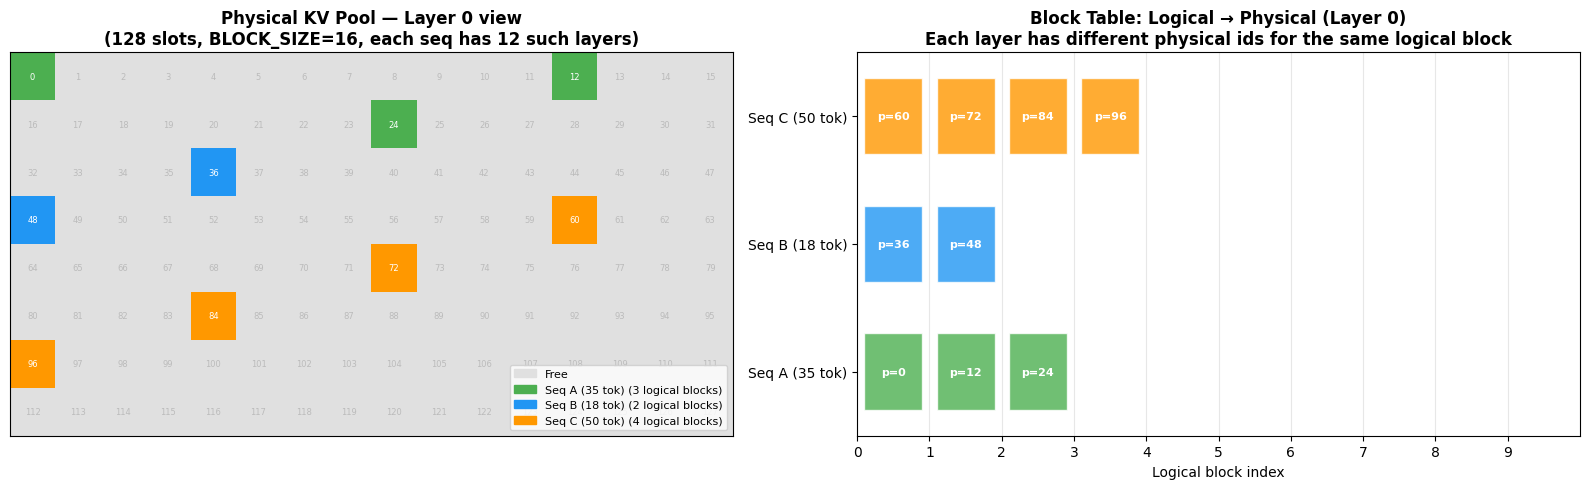

Saved: paged_attention_block_table.png


In [35]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.colors import ListedColormap

    # ── Viz 1: Block table layout ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Pool must be large enough: 3 seqs × max_logical_blocks × n_layers
    # Seq C has 50 tokens → ceil(50/16)=4 logical blocks → 4×12=48 slots
    # Total for 3 seqs ≈ (3+2+4) logical blocks × 12 layers = 108 slots → use 128
    sim_alloc = BlockAllocator(128)
    sim_seqs  = [
        ('Seq A (35 tok)', 35),
        ('Seq B (18 tok)', 18),
        ('Seq C (50 tok)', 50),
    ]
    sim_tables = []
    for name, n in sim_seqs:
        bt = LayeredBlockTable(seq_id=len(sim_tables), n_layers=cfg.n_layers)
        bt.append_tokens(n, sim_alloc)
        sim_tables.append((name, n, bt))

    # ── Plot 1: Physical pool grid (showing layer 0's block ids) ─────────
    ax = axes[0]
    # Show layer 0 allocation — representative of all layers
    pool_rows = 8
    pool_cols = 16   # 128 slots → 8×16 grid
    grid = np.full((pool_rows, pool_cols), -1)

    colors = ['#4CAF50', '#2196F3', '#FF9800']
    for seq_idx, (name, n_tok, bt) in enumerate(sim_tables):
        for phys_id in bt.block_ids[0]:   # ← layer 0's physical ids
            row, col = divmod(phys_id, pool_cols)
            if row < pool_rows:
                grid[row, col] = seq_idx

    cmap = ListedColormap(['#E0E0E0', colors[0], colors[1], colors[2]])
    ax.imshow(grid, cmap=cmap, vmin=-1, vmax=2, aspect='auto')

    for r in range(pool_rows):
        for c in range(pool_cols):
            bid = r * pool_cols + c
            ax.text(c, r, str(bid), ha='center', va='center', fontsize=6,
                    color='white' if grid[r, c] >= 0 else '#bbb')

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'Physical KV Pool — Layer 0 view\n'
                 f'({pool_rows*pool_cols} slots, BLOCK_SIZE={BLOCK_SIZE}, '
                 f'each seq has {cfg.n_layers} such layers)', fontweight='bold')
    patches = [mpatches.Patch(color='#E0E0E0', label='Free')]
    for i, (name, n, bt) in enumerate(sim_tables):
        patches.append(mpatches.Patch(color=colors[i],
                                      label=f'{name} ({bt.num_blocks} logical blocks)'))
    ax.legend(handles=patches, loc='lower right', fontsize=8)

    # ── Plot 2: Logical→physical mapping for layer 0 ─────────────────────
    ax = axes[1]
    ax.set_xlim(0, 10); ax.set_ylim(-0.5, len(sim_tables) - 0.5)
    ax.set_yticks(range(len(sim_tables)))
    ax.set_yticklabels([name for name, _, _ in sim_tables])
    ax.set_xlabel('Logical block index')
    ax.set_title('Block Table: Logical → Physical (Layer 0)\n'
                 'Each layer has different physical ids for the same logical block',
                 fontweight='bold')
    ax.set_xticks(range(10))
    ax.grid(True, alpha=0.3, axis='x')

    for seq_idx, (name, n_tok, bt) in enumerate(sim_tables):
        for log_idx, phys_id in enumerate(bt.block_ids[0]):   # ← layer 0
            ax.barh(seq_idx, 0.8, left=log_idx + 0.1, height=0.6,
                    color=colors[seq_idx], alpha=0.8, edgecolor='white')
            ax.text(log_idx + 0.5, seq_idx, f'p={phys_id}',
                    ha='center', va='center', fontsize=8,
                    color='white', fontweight='bold')

    plt.tight_layout()
    plt.savefig('paged_attention_block_table.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved: paged_attention_block_table.png')

except ImportError as e:
    print(f'matplotlib not available: {e}')

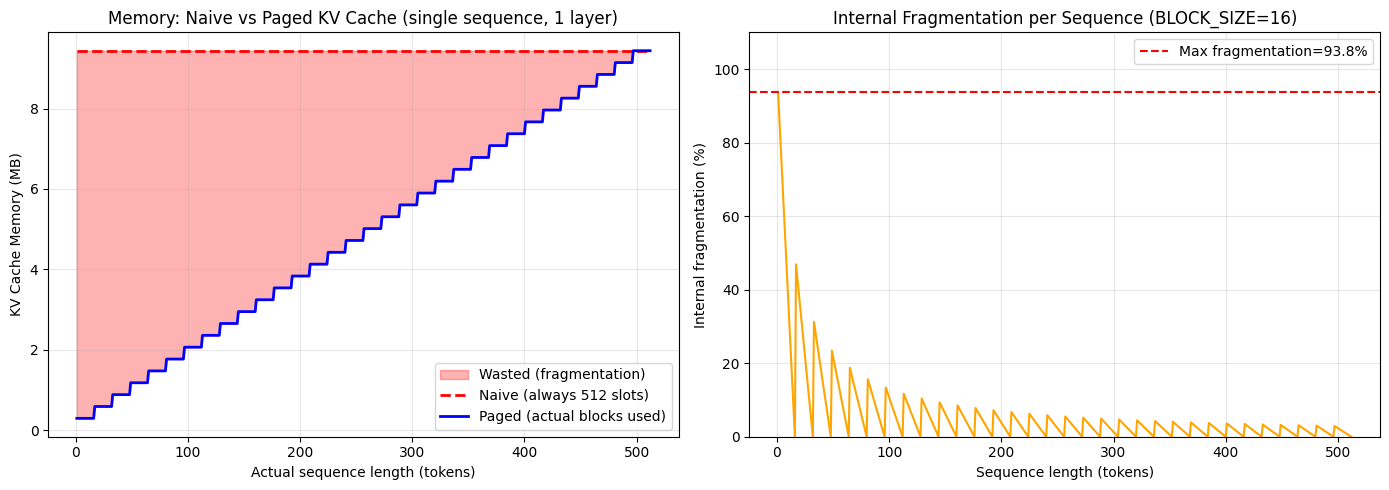

Saved: paged_attention_memory.png


In [36]:
try:
    import matplotlib.pyplot as plt

    # ── Viz 2: Memory savings across generation lengths ──────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    seq_lens  = list(range(1, 513))
    nl, nkv, hd = cfg.n_layers, cfg.n_kv_heads, cfg.head_dim

    naive_mb  = [naive_cache_memory(1, cfg.max_seq_len, nl, nkv, hd) / 1e6
                 for _ in seq_lens]
    paged_mb = [paged_cache_memory([l], BLOCK_SIZE, nl, nkv, hd) / 1e6
            for l in seq_lens]

    ax = axes[0]
    ax.fill_between(seq_lens, naive_mb, paged_mb, alpha=0.3, color='red', label='Wasted (fragmentation)')
    ax.plot(seq_lens, naive_mb, 'r--', linewidth=2, label=f'Naive (always {cfg.max_seq_len} slots)')
    ax.plot(seq_lens, paged_mb, 'b-',  linewidth=2, label='Paged (actual blocks used)')
    ax.set_xlabel('Actual sequence length (tokens)')
    ax.set_ylabel('KV Cache Memory (MB)')
    ax.set_title('Memory: Naive vs Paged KV Cache (single sequence, 1 layer)')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Internal fragmentation
    ax = axes[1]
    frag_pcts = [(math.ceil(l/BLOCK_SIZE)*BLOCK_SIZE - l) / (math.ceil(l/BLOCK_SIZE)*BLOCK_SIZE) * 100
                 for l in seq_lens]
    ax.plot(seq_lens, frag_pcts, color='orange', linewidth=1.5)
    ax.axhline((BLOCK_SIZE-1)/BLOCK_SIZE*100, color='red', linestyle='--',
               label=f'Max fragmentation={(BLOCK_SIZE-1)/BLOCK_SIZE*100:.1f}%')
    ax.set_xlabel('Sequence length (tokens)')
    ax.set_ylabel('Internal fragmentation (%)')
    ax.set_title(f'Internal Fragmentation per Sequence (BLOCK_SIZE={BLOCK_SIZE})')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 110)

    plt.tight_layout()
    plt.savefig('paged_attention_memory.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved: paged_attention_memory.png')

except ImportError:
    pass

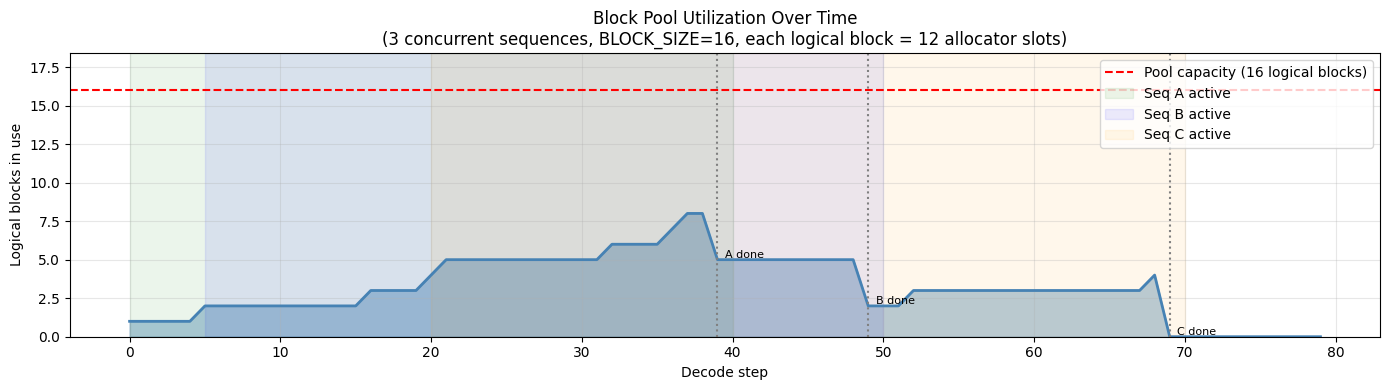

Saved: paged_attention_utilization.png


In [37]:
try:
    import matplotlib.pyplot as plt

    # ── Viz 3: Step-by-step block allocation during generation ────────────
    fig, ax = plt.subplots(figsize=(14, 4))

    # Pool must be n_layers × logical_blocks_needed
    # 3 seqs × 80 steps max → ceil(80/16)=5 logical blocks each → 15 logical max
    # allocator slots = 15 × n_layers = 15 × 12 = 180 → use 192
    _n = cfg.n_layers
    sim_pool = BlockAllocator(192)
    event_log = []

    bt_a = LayeredBlockTable(0, n_layers=_n)
    bt_b = LayeredBlockTable(1, n_layers=_n)
    bt_c = LayeredBlockTable(2, n_layers=_n)

    for step in range(80):
        if step < 40:        bt_a.append_token(sim_pool)
        if 5 <= step < 50:   bt_b.append_token(sim_pool)
        if 20 <= step < 70:  bt_c.append_token(sim_pool)
        if step == 39:       bt_a.free(sim_pool)
        if step == 49:       bt_b.free(sim_pool)
        if step == 69:       bt_c.free(sim_pool)
        event_log.append(sim_pool.n_used)

    # Convert allocator slots → logical blocks for readability
    logical_log = [v / _n for v in event_log]
    pool_logical = 192 / _n

    steps = list(range(80))
    ax.fill_between(steps, logical_log, alpha=0.4, color='steelblue')
    ax.plot(steps, logical_log, color='steelblue', linewidth=2)
    ax.axhline(pool_logical, color='red', linestyle='--',
               label=f'Pool capacity ({pool_logical:.0f} logical blocks)')

    ax.axvspan(0,  40, alpha=0.08, color='green',  label='Seq A active')
    ax.axvspan(5,  50, alpha=0.08, color='blue',   label='Seq B active')
    ax.axvspan(20, 70, alpha=0.08, color='orange', label='Seq C active')

    for evt, txt in [(39, 'A done'), (49, 'B done'), (69, 'C done')]:
        ax.axvline(evt, color='gray', linestyle=':')
        ax.text(evt + 0.5, logical_log[evt] + 0.1, txt, fontsize=8)

    ax.set_xlabel('Decode step')
    ax.set_ylabel('Logical blocks in use')
    ax.set_title(f'Block Pool Utilization Over Time\n'
                 f'(3 concurrent sequences, BLOCK_SIZE={BLOCK_SIZE}, '
                 f'each logical block = {_n} allocator slots)')
    ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, pool_logical * 1.15)

    plt.tight_layout()
    plt.savefig('paged_attention_utilization.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved: paged_attention_utilization.png')

except ImportError:
    pass